# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

In [2]:
data_raw = pd.read_csv('data/cash_app_report_1782913510031.csv')
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-07-01 09:42:52 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,SAP,$157.55,0.126940,COMPLETE,$20 Sale of SAP,NaN,Cash Balance
1,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.371830,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
2,2026-07-01 09:41:36 EDT,NaN,Deposits,USD,$100.00,$0.00,$100.00,NaN,NaN,NaN,COMPLETE,Add Cash,NaN,Visa debit 3333
3,2026-07-01 09:41:18 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,HTZ,$2.22,4.509170,COMPLETE,$10 Purchase of Hertz,NaN,Cash Balance
4,2026-07-01 09:40:21 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,AAPL,$292.05,0.034240,COMPLETE,$10 Purchase of Apple,NaN,Cash Balance
5,2026-07-01 09:35:51 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WFC,$83.02,0.240900,COMPLETE,$20 Sale of Wells Fargo,NaN,Cash Balance
6,2026-07-01 09:30:23 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,AMZN,$239.77,0.041700,COMPLETE,$10 Purchase of Amazon,NaN,Cash Balance
7,2026-07-01 09:30:21 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,MSFT,$380.92,0.026250,COMPLETE,$10 Purchase of Microsoft,NaN,Cash Balance
8,2026-07-01 09:30:01 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,OKTA,$137.86,0.072530,COMPLETE,$10 Sale of Okta,NaN,Cash Balance
9,2026-07-01 09:30:01 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,VOO,$684.60,0.014600,COMPLETE,$10 Purchase of Vanguard S&P 500 ETF,NaN,Cash Balance


In [3]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
73,2026-06-22 09:30:03 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,PZZA,$35.71,0.28003,COMPLETE,$10 Sale of Papa John's,NaN,Cash Balance
51,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance
251,2026-06-04 09:30:00 EDT,NaN,NaN,USD,$10.10,$0.00,$10.10,NOBL,$54.04,0.18695,COMPLETE,$10.10 Sale of ProShares S&P 500 Dividend Aris...,NaN,Cash Balance
8,2026-07-01 09:30:01 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,OKTA,$137.86,0.07253,COMPLETE,$10 Sale of Okta,NaN,Cash Balance
56,2026-06-22 09:30:44 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HOOD,$108.10,0.09250,COMPLETE,$10 Sale of Robinhood Markets,NaN,Cash Balance
249,2026-06-04 09:30:03 EDT,NaN,NaN,USD,$9.87,$0.00,$9.87,KWEB,$27.27,0.36205,COMPLETE,$9.87 Sale of KraneShares Trust KraneShares CS...,NaN,Cash Balance
1,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.37183,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
60,2026-06-22 09:30:20 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DKS,$237.13,0.04217,COMPLETE,$10 Sale of Dick's Sporting Goods,NaN,Cash Balance
0,2026-07-01 09:42:52 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,SAP,$157.55,0.12694,COMPLETE,$20 Sale of SAP,NaN,Cash Balance
117,2026-06-16 11:47:45 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,UHAL,$62.78,0.15928,COMPLETE,$10 Sale of U-Haul,NaN,Cash Balance


In [4]:
data_raw['Asset Amount'].fillna(None).astype(float)

0      0.12694
1      2.37183
2          NaN
3      4.50917
4      0.03424
        ...   
618        NaN
619        NaN
620        NaN
621        NaN
622        NaN
Name: Asset Amount, Length: 623, dtype: float64

In [5]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
427,2026-06-03 13:30:01+00:00,-10.00,-10.00,14.07,0.71073,0.0,LYFT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Lyft,NaN
419,2026-06-03 13:30:03+00:00,-10.00,-10.00,149.70,0.06680,0.0,PLTR,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Palantir Technologies,NaN
385,2026-06-03 13:30:16+00:00,-10.00,-10.00,697.19,0.01434,0.0,VOO,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard S&P 500 ETF,NaN
361,2026-06-03 13:52:36+00:00,-10.00,-10.00,298.71,0.03347,0.0,JPM,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of JPMorgan Chase,NaN
242,2026-06-04 13:30:12+00:00,-10.00,-10.00,90.81,0.11012,0.0,CRCL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Circle,NaN
195,2026-06-12 04:00:00+00:00,0.05,0.05,NaN,0.00000,0.0,DOW,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.05 Dividend from Dow,NaN
148,2026-06-16 13:30:12+00:00,-5.00,-5.00,81.15,0.06161,0.0,KO,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Coca-Cola,NaN
149,2026-06-16 13:30:12+00:00,-5.00,-5.00,33.19,0.15064,0.0,PZZA,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Papa John's,NaN
125,2026-06-16 15:43:55+00:00,-5.00,-5.00,189.57,0.02637,0.0,ORCL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Oracle,NaN
101,2026-06-18 14:11:03+00:00,-5.00,-5.00,333.15,0.01500,0.0,JPM,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of JPMorgan Chase,NaN


In [6]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
616,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
617,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
618,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
620,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
621,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
622,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


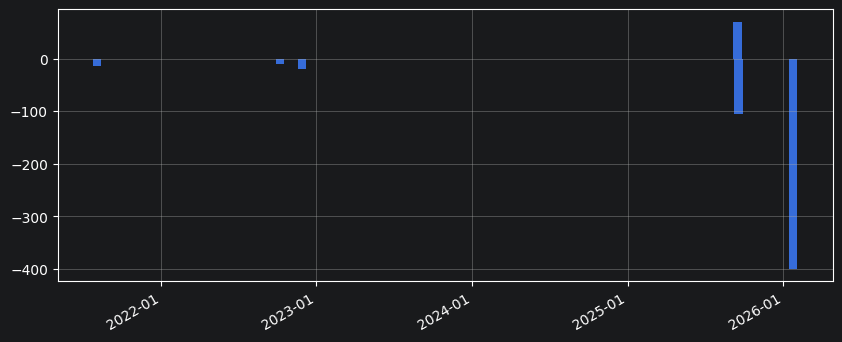

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [8]:
data.describe()

,net_amount,amount,asset_price,asset_amount,fee
count,623.000000,623.000000,503.000000,623.000000,620.000000
mean,0.242215,0.251910,4092.315805,0.141220,-0.009742
std,38.950020,38.947668,16156.532314,0.339573,0.054253
min,-400.000000,-400.000000,2.220000,0.000000,-0.500000
25%,-10.000000,-10.000000,56.425000,0.006670,0.000000
50%,-10.000000,-10.000000,132.210000,0.043290,0.000000
75%,-1.000000,-1.000000,301.315000,0.127015,0.000000
max,200.000000,200.000000,80346.140000,4.509170,0.000000


In [9]:
data.nunique().sort_values(ascending=False)

asset_price     495
asset_amount    494
date            484
notes           370
asset_type      166
amount           56
net_amount       55
trans_type       10
trans_id          7
fee               6
account           5
name_trans        5
status            2
currency          1
dtype: int64

In [10]:
data['asset_type'].value_counts()

asset_type
BTC     28
XYZ     13
JPM     12
WFC     11
AMZN    10
        ..
RUM      1
CAT      1
ADBE     1
JEPI     1
CBRS     1
Name: count, Length: 166, dtype: int64

Text(0, 0.5, 'Count')

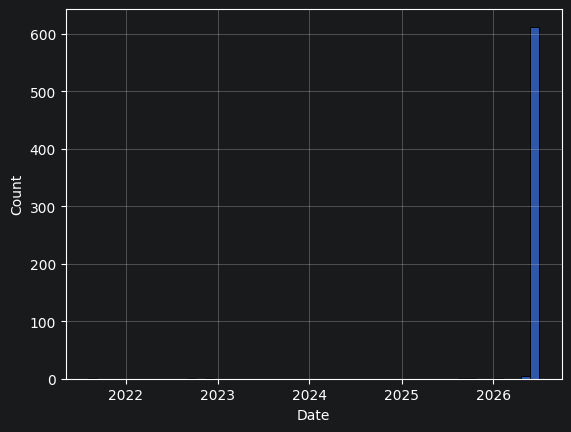

In [11]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [12]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-02-16,2026-05-27,2026-05-29,2026-06-02,2026-06-03,2026-06-16,2026-06-22,2026-06-26,2026-07-01


In [13]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,28,-177.16,"(-24.5, -9.8, -4.9, -0.98, 5.0, 10.0, 20.0)",7
XYZ,13,-171.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
JPM,12,-70.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
WFC,11,-51.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
META,10,-70.95,"(-10.0, -5.0, -1.0, 0.05)",4
AMZN,10,-161.00,"(-50.0, -25.0, -10.0, -1.0)",4
ORCL,10,-85.00,"(-10.0, -5.0)",2
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4
MCD,9,-89.80,"(-25.0, -10.0, -5.0, 0.2)",4


In [14]:
data['currency'].value_counts()

currency
USD    623
Name: count, dtype: int64

In [15]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    438
Deposits                      64
Stock Sell                    37
Stock Dividends               34
Bitcoin Buy                   23
Savings Internal Transfer     12
P2P                            6
Bitcoin Sell                   5
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [16]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,23,5,438,34,37,537
BTC,23,5,0,0,0,28
XYZ,0,0,12,0,1,13
JPM,0,0,10,0,2,12
WFC,0,0,9,0,2,11
AMZN,0,0,10,0,0,10
META,0,0,9,1,0,10
PZZA,0,0,9,0,1,10
ORCL,0,0,10,0,0,10


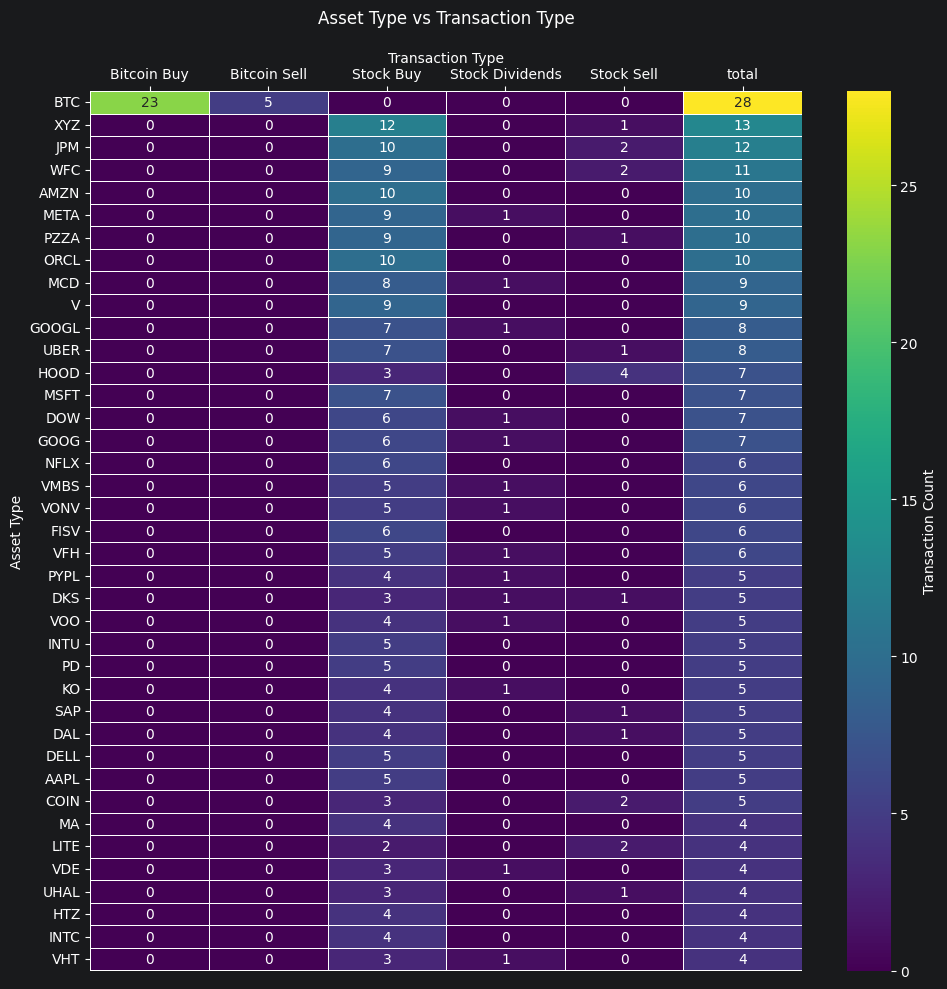

In [17]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [18]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
23,2026-06-26 17:38:10+00:00,-5.0,-4.9,60331.07,0.000081,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00008122,NaN
78,2026-06-20 20:54:15+00:00,9.8,10.0,63371.65,0.000158,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015780,NaN
80,2026-06-20 11:51:40+00:00,-5.0,-4.9,64191.63,0.000076,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007633,NaN
89,2026-06-18 17:13:37+00:00,19.6,20.0,61888.37,0.000323,-0.4,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032316,NaN
171,2026-06-16 12:39:28+00:00,4.9,5.0,66069.72,0.000076,-0.1,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00007568,NaN


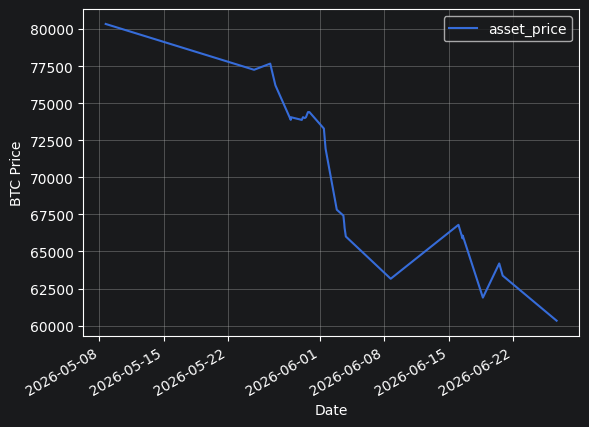

In [19]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [20]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     23
Bitcoin Sell     5
Name: count, dtype: int64

In [21]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-242.0
Bitcoin Sell,58.8


In [22]:
data_btc['net_amount'].sum()

np.float64(-183.2)

In [23]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003257
Bitcoin Sell    0.000949
Name: asset_amount, dtype: float64

In [24]:
data_btc['asset_amount'].sum()

np.float64(0.00420657)

In [25]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00230821)

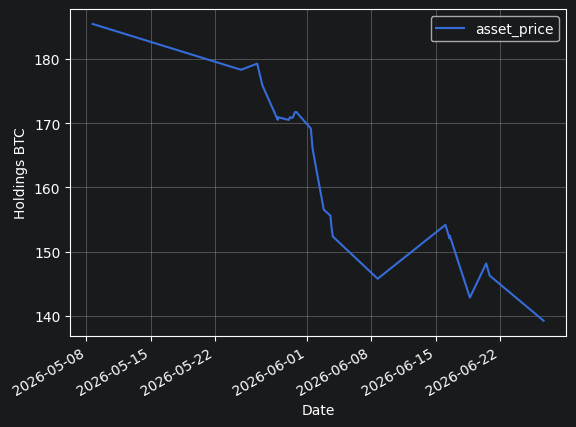

In [26]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [27]:
data_btc['asset_price'] * data_btc['asset_amount']

23      4.900090
78     10.000046
80      4.899747
89     19.999846
171     5.000156
172     4.999899
175     4.900240
211    19.999798
291     9.799846
318     9.800287
342     0.980144
439     9.800221
450     0.979969
467     9.799652
525     4.900136
527     9.799865
530     4.900112
531     9.799903
535     9.799965
539    24.500200
546    24.499951
550    24.500084
569     9.799731
573     9.800031
596    24.499991
613     9.799898
614     4.900356
615     9.799819
dtype: float64

In [28]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
22,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
51,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
133,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
178,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
226,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
302,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
314,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
327,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
365,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
368,2026-06-03 13:33:56+00:00,-1.0,-1.0,72.82,0.01373,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Block,NaN


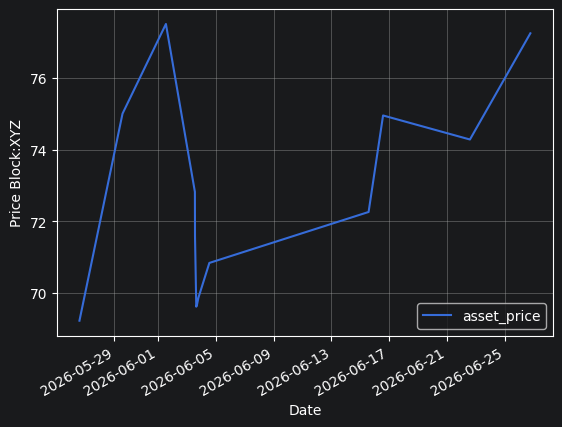

In [29]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [30]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     28
XYZ     13
JPM     12
WFC     11
META    10
        ..
RUM      1
BIV      1
SHOP     1
SLAB     1
ZG       1
Name: amount, Length: 166, dtype: int64

In [31]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [32]:
data['asset_amount'].describe()

count    623.000000
mean       0.141220
std        0.339573
min        0.000000
25%        0.006670
50%        0.043290
75%        0.127015
max        4.509170
Name: asset_amount, dtype: float64

In [33]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
)
asset_holding_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-22 13:30:49+00:00,37.937295,9.999493,16.180396,9.9981,0.000000,9.999577,19.549552,21.050186,9.042617,30.069556,...,0.000000,85.406771,23.724046,29.991989,0.0,174.501547,40.190894,19.954137,9.999727,9.999925
2026-06-03 19:41:22+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,0.000000,14.039852,20.071824,...,0.000000,63.030258,18.724670,29.991989,0.0,131.892037,30.191289,9.953370,0.000000,0.000000
2026-06-16 12:03:53+00:00,28.691891,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,11.051107,14.039852,20.071824,...,0.000000,77.322328,18.724670,29.991989,0.0,171.075624,30.191289,9.953370,9.999727,9.999925
2026-06-03 13:30:19+00:00,20.147721,9.999493,9.010079,9.9981,10.098907,0.000000,19.549552,0.000000,14.039852,0.000000,...,0.000000,30.766264,9.686363,19.992722,0.0,93.073427,0.000000,9.953370,0.000000,0.000000
2026-06-10 13:30:11+00:00,28.691891,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,11.051107,14.039852,20.071824,...,0.000000,77.322328,18.724670,29.991989,0.0,154.936279,30.191289,9.953370,9.999727,9.999925
2026-07-01 13:30:21+00:00,37.937295,9.999493,16.180396,9.9981,0.000000,9.999577,19.549552,21.050186,9.042617,30.069556,...,26.856968,75.498388,23.724046,29.991989,0.0,181.056739,40.190894,19.954137,9.999727,9.999925
2026-06-22 14:55:47+00:00,37.937295,9.999493,16.180396,9.9981,0.000000,9.999577,19.549552,21.050186,9.042617,30.069556,...,0.000000,75.498388,23.724046,29.991989,0.0,171.057249,40.190894,19.954137,9.999727,9.999925
2026-06-16 13:30:01+00:00,28.691891,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,11.051107,14.039852,20.071824,...,0.000000,77.322328,18.724670,29.991989,0.0,171.075624,30.191289,9.953370,9.999727,9.999925
2026-06-03 13:55:07+00:00,20.147721,9.999493,9.010079,9.9981,10.098907,0.000000,19.549552,0.000000,14.039852,0.000000,...,0.000000,31.527923,9.686363,19.992722,0.0,99.663815,0.000000,9.953370,0.000000,0.000000


In [34]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3397.5048193000002)

In [35]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-01 13:35:51+00:00,0.011166,0.002943,0.004762,0.002943,0.0,0.002943,0.005754,0.006196,0.002662,0.00885,...,0.007905,0.016335,0.006983,0.008828,0.0,0.053291,0.01183,0.005873,0.002943,0.002943
2026-07-01 13:40:21+00:00,0.014109,0.002943,0.004762,0.002943,0.0,0.002943,0.005754,0.006196,0.002662,0.00885,...,0.007905,0.016335,0.006983,0.008828,0.0,0.053291,0.01183,0.005873,0.002943,0.002943
2026-07-01 13:41:18+00:00,0.014109,0.002943,0.004762,0.002943,0.0,0.002943,0.005754,0.006196,0.002662,0.00885,...,0.007905,0.016335,0.006983,0.008828,0.0,0.053291,0.01183,0.005873,0.002943,0.002943
2026-07-01 13:42:13+00:00,0.014109,0.002943,0.004762,0.002943,0.0,0.002943,0.005754,0.006196,0.002662,0.00885,...,0.002020,0.016335,0.006983,0.008828,0.0,0.053291,0.01183,0.005873,0.002943,0.002943
2026-07-01 13:42:52+00:00,0.014109,0.002943,0.004762,0.002943,0.0,0.002943,0.005754,0.006196,0.002662,0.00885,...,0.002020,0.016335,0.006983,0.008828,0.0,0.053291,0.01183,0.005873,0.002943,0.002943


In [36]:
asset_price_rel.iloc[-1].describe()

count    166.000000
mean       0.006024
std        0.007537
min        0.000000
25%        0.002732
50%        0.004278
75%        0.006982
max        0.053291
Name: 2026-07-01 13:42:52+00:00, dtype: float64

In [37]:
asset_price_rel.iloc[-1].sort_values(ascending=False).head()

asset_type
XYZ     0.053291
AMZN    0.044036
V       0.030662
DELL    0.030255
UBER    0.028305
Name: 2026-07-01 13:42:52+00:00, dtype: float64

In [38]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-01 13:35:51+00:00,0.011166,0.002943,0.004762,0.002943,0.0,0.002943,0.005754,0.006196,0.002662,0.00885,...,0.007905,0.016335,0.006983,0.008828,0.0,0.053291,0.01183,0.005873,0.002943,0.002943
2026-07-01 13:40:21+00:00,0.014109,0.002943,0.004762,0.002943,0.0,0.002943,0.005754,0.006196,0.002662,0.00885,...,0.007905,0.016335,0.006983,0.008828,0.0,0.053291,0.01183,0.005873,0.002943,0.002943
2026-07-01 13:41:18+00:00,0.014109,0.002943,0.004762,0.002943,0.0,0.002943,0.005754,0.006196,0.002662,0.00885,...,0.007905,0.016335,0.006983,0.008828,0.0,0.053291,0.01183,0.005873,0.002943,0.002943
2026-07-01 13:42:13+00:00,0.014109,0.002943,0.004762,0.002943,0.0,0.002943,0.005754,0.006196,0.002662,0.00885,...,0.002020,0.016335,0.006983,0.008828,0.0,0.053291,0.01183,0.005873,0.002943,0.002943
2026-07-01 13:42:52+00:00,0.014109,0.002943,0.004762,0.002943,0.0,0.002943,0.005754,0.006196,0.002662,0.00885,...,0.002020,0.016335,0.006983,0.008828,0.0,0.053291,0.01183,0.005873,0.002943,0.002943


In [39]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 17:41:52+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 17:17:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 18:57:59+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-01 13:30:21+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:43:16+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-27 13:33:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:27:58+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 18:46:11+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 17:41:52+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.0,1.012014,1.000000,0.976969,1.0,1.006356,1.000000,1.000000,1.0,1.0
2026-06-22 17:17:10+00:00,0.969248,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.0,1.071179,0.921293,0.976969,1.0,1.072945,1.005550,0.995338,1.0,1.0
2026-06-22 18:57:59+00:00,0.969248,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.0,1.071179,0.921293,0.976969,1.0,1.072945,1.005550,0.995338,1.0,1.0
2026-07-01 13:30:21+00:00,0.969248,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.0,1.071179,0.921293,0.976969,1.0,1.115701,1.005550,0.995338,1.0,1.0
2026-06-15 13:30:04+00:00,1.018386,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.0,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.000000,1.0,1.0
2026-06-03 19:43:16+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.0,1.016406,0.968648,0.976969,1.0,1.009245,0.997325,1.000000,1.0,1.0
2026-05-27 13:33:02+00:00,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.0
2026-06-03 19:27:58+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.0,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0
2026-06-03 18:46:11+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.0,1.012014,0.968648,0.976969,1.0,1.006356,1.000000,1.000000,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

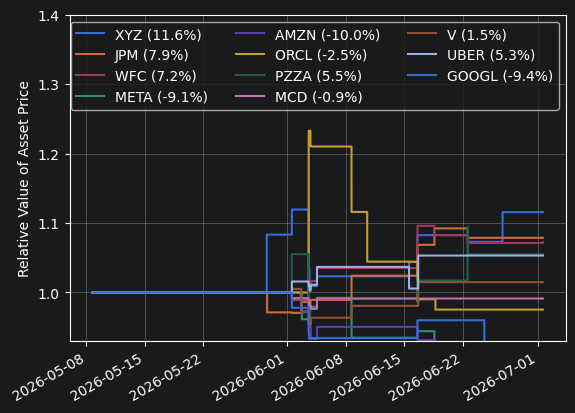

In [41]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [42]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-07-01 13:35:51+00:00    1.115701
2026-07-01 13:40:21+00:00    1.115701
2026-07-01 13:41:18+00:00    1.115701
2026-07-01 13:42:13+00:00    1.115701
2026-07-01 13:42:52+00:00    1.115701
Name: XYZ, Length: 383, dtype: float64

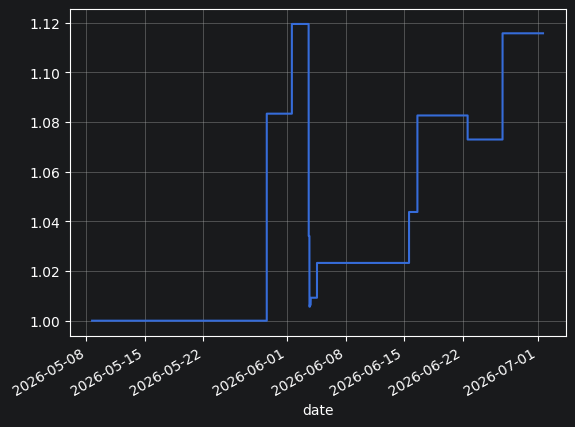

In [43]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [44]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
)
div_data

,date,amount,asset_type,notes
12,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
13,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
14,2026-07-01,0.09,M,$0.09 Dividend from Macy's
15,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing
16,2026-07-01,0.12,PSKY,$0.12 Dividend from Paramount Skydance
17,2026-06-30,0.01,AVGO,$0.01 Dividend from Broadcom
18,2026-06-30,0.14,VBR,$0.14 Dividend from Small Cap Value ETF Vanguard
19,2026-06-30,0.02,GSLC,$0.02 Dividend from Goldman Sachs ActiveBeta U...
20,2026-06-30,0.07,VOO,$0.07 Dividend from Vanguard S&P 500 ETF
21,2026-06-29,0.02,CXSE,$0.02 Dividend from WisdomTree China ex-State-...


In [45]:
div_data['amount'].sum()

np.float64(3.52)

In [46]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
27,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
12,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
34,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
173,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
30,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
24,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
13,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
25,2026-06-26,0.17,DKS,$0.17 Dividend from Dick's Sporting Goods
44,2026-06-23,0.16,VSS,$0.16 Dividend from Vanguard FTSE All World ex...
15,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing


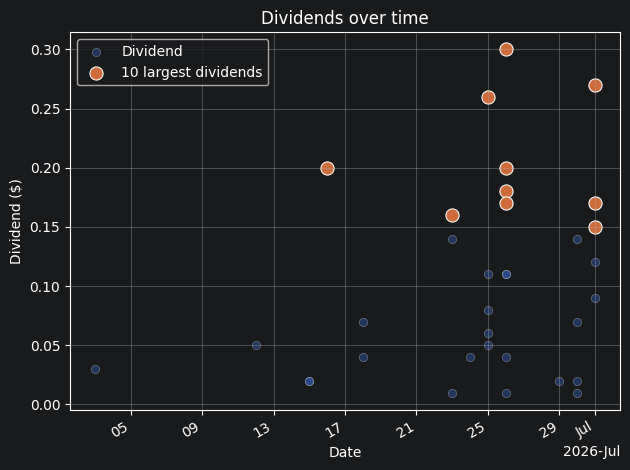

In [47]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [48]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
349,2026-06-03 15:10:50+00:00,-10.00,48.06,$10 Purchase of Vanguard Total International B...,BNDX
393,2026-06-03 13:30:12+00:00,-1.00,46.56,$1 Purchase of Vanguard Mortgage-Backed Securi...,VMBS
329,2026-06-03 15:49:05+00:00,-10.00,275.30,$10 Purchase of Vanguard Health Care ETF,VHT
322,2026-06-03 15:53:29+00:00,-10.00,54.44,$10 Purchase of Vanguard Long-Treasury ETF,VGLT
410,2026-06-03 13:30:07+00:00,-10.00,125.39,$10 Purchase of Vanguard Financials ETF,VFH
126,2026-06-16 15:43:17+00:00,-5.00,46.83,$5 Purchase of Vanguard Mortgage-Backed Securi...,VMBS
76,2026-06-22 13:30:00+00:00,-5.00,238.55,$5 Purchase of Small Cap Value ETF Vanguard,VBR
161,2026-06-16 13:30:05+00:00,-5.00,132.21,$5 Purchase of Vanguard Financials ETF,VFH
163,2026-06-16 13:30:03+00:00,-5.00,155.47,$5 Purchase of Energy ETF Vanguard,VDE
29,2026-06-26 04:00:00+00:00,0.11,NaN,$0.11 Dividend from Vanguard Consumer Staples ...,VDC


In [49]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VFH     6
VONV    6
VMBS    6
VOO     5
VNQ     4
VHT     4
VDE     4
VSS     4
VBR     3
VCR     3
VDC     3
VONG    3
VTEB    2
VGLT    2
BNDX    2
BIV     1
Name: count, dtype: int64

In [50]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
349,2026-06-03 15:10:50+00:00,-10.00,48.06,BNDX,Vanguard Total International Bond ETF
393,2026-06-03 13:30:12+00:00,-1.00,46.56,VMBS,Vanguard Mortgage-Backed Securities ETF
329,2026-06-03 15:49:05+00:00,-10.00,275.30,VHT,Vanguard Health Care ETF
322,2026-06-03 15:53:29+00:00,-10.00,54.44,VGLT,Vanguard Long-Treasury ETF
410,2026-06-03 13:30:07+00:00,-10.00,125.39,VFH,Vanguard Financials ETF
126,2026-06-16 15:43:17+00:00,-5.00,46.83,VMBS,Vanguard Mortgage-Backed Securities ETF
76,2026-06-22 13:30:00+00:00,-5.00,238.55,VBR,Small Cap Value ETF Vanguard
161,2026-06-16 13:30:05+00:00,-5.00,132.21,VFH,Vanguard Financials ETF
163,2026-06-16 13:30:03+00:00,-5.00,155.47,VDE,Energy ETF Vanguard
29,2026-06-26 04:00:00+00:00,0.11,NaN,VDC,NaN


In [51]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VFH         Vanguard Financials ETF                        5
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VONV        Vanguard Russell 1000 Value ETF                5
VOO         Vanguard S&P 500 ETF                           4
VDE         Energy ETF Vanguard                            3
VHT         Vanguard Health Care ETF                       3
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
BNDX        Vanguard Total International Bond ETF          2
VBR         Small Cap Value ETF Vanguard                   2
VCR         Vanguard Consumer Discretionary ETF            2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VGLT        Vanguard Long-Treasury ETF                     2
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 1000 Growth ETF               2
VTEB        Vanguard Tax-Exempt Bond ETF                   2
BIV         Vanguard Intermed

In [52]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VFH,VONV,VMBS,VOO,VNQ,VHT,VDE,VSS,VBR,VCR,VDC,VONG,VTEB,VGLT,BNDX,BIV
date,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,NaN,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
vanguard_trans_count

asset_type
VFH     6
VONV    6
VMBS    6
VOO     5
VNQ     4
VHT     4
VDE     4
VSS     4
VBR     3
VCR     3
VDC     3
VONG    3
VTEB    2
VGLT    2
BNDX    2
BIV     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

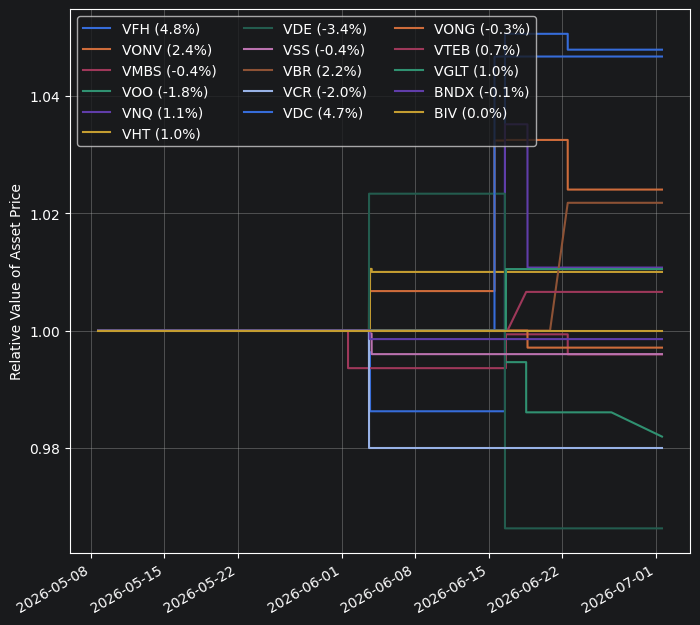

In [54]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [55]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
2,2026-07-01 13:41:36+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
77,2026-06-21 21:31:19+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
79,2026-06-20 12:23:07+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
90,2026-06-18 17:13:20+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
174,2026-06-16 03:43:50+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
607,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
608,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
609,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
610,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [56]:
data_deposits['net_amount'].sum()

np.float64(5635.96)

In [57]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,64.0,88.061875,50.33409,1.0,50.0,100.0,100.0,200.0


In [58]:
data_deposits['net_amount'].cumsum()

2       100.00
77      200.00
79      300.00
90      400.00
174     500.00
        ...   
607    5530.96
608    5540.96
609    5590.96
610    5610.96
611    5635.96
Name: net_amount, Length: 64, dtype: float64

In [59]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
611,2026-05-26 19:39:34+00:00,25.00
610,2026-05-26 21:58:29+00:00,45.00
609,2026-05-27 00:43:01+00:00,95.00
608,2026-05-27 00:56:05+00:00,105.00
607,2026-05-27 00:56:27+00:00,205.00
...,...,...
174,2026-06-16 03:43:50+00:00,5235.96
90,2026-06-18 17:13:20+00:00,5335.96
79,2026-06-20 12:23:07+00:00,5435.96
77,2026-06-21 21:31:19+00:00,5535.96


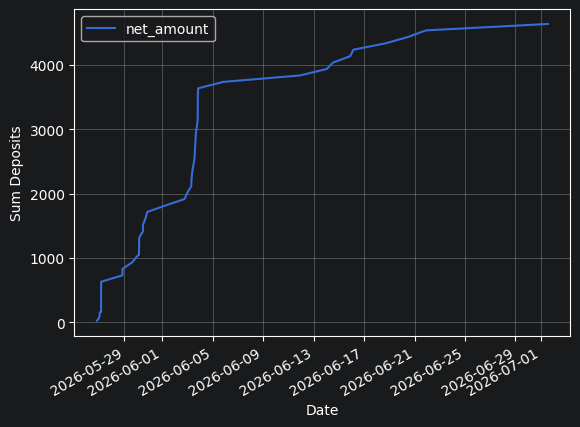

In [60]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [61]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [62]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    4300.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64